# Tic-Tac-Toe Project: Finalize Data Acquisition
**Student:** Nahida Iqbal  
**Module:** 3.6  

## Objective
This notebook simulates 1,000 complete rounds of Tic-Tac-Toe, stores the gameplay results in a pandas DataFrame, validates the final dataset, and reports basic findings. A fixed random seed makes the results reproducible.

## 1. Import libraries

In [1]:
import random

import matplotlib.pyplot as plt
import pandas as pd

RANDOM_SEED = 42
NUMBER_OF_GAMES = 1000
random.seed(RANDOM_SEED)

## 2. Define the game rules
The board is stored as a list of nine positions. Each simulated player randomly chooses an available position. The game ends when a player completes a row, column, or diagonal, or when the board is full.

In [2]:
WINNING_LINES = [
    (0, 1, 2),
    (3, 4, 5),
    (6, 7, 8),
    (0, 3, 6),
    (1, 4, 7),
    (2, 5, 8),
    (0, 4, 8),
    (2, 4, 6),
]


def find_winner(board):
    """Return the winning player and line, or (None, None)."""
    for line in WINNING_LINES:
        first, second, third = line
        if (
            board[first] != ' '
            and board[first] == board[second] == board[third]
        ):
            return board[first], line
    return None, None


def simulate_game(game_id):
    """Simulate one game and return a dictionary of game data."""
    board = [' '] * 9
    current_player = 'X'
    move_history = []

    while True:
        available_positions = [
            index for index, value in enumerate(board) if value == ' '
        ]
        selected_position = random.choice(available_positions)
        board[selected_position] = current_player
        move_history.append(selected_position + 1)

        winner, winning_line = find_winner(board)
        if winner is not None:
            return {
                'game_id': game_id,
                'result': f'{winner} Win',
                'winner': winner,
                'number_of_moves': len(move_history),
                'ended_in_draw': False,
                'winning_line': str(winning_line),
                'move_history': str(move_history),
            }

        if not available_positions[1:]:
            return {
                'game_id': game_id,
                'result': 'Draw',
                'winner': 'None',
                'number_of_moves': len(move_history),
                'ended_in_draw': True,
                'winning_line': 'None',
                'move_history': str(move_history),
            }

        current_player = 'O' if current_player == 'X' else 'X'

## 3. Simulate all rounds and create the DataFrame
Each dictionary becomes one row. Therefore, each row in `gameplay_df` represents one complete game.

In [3]:
game_records = [
    simulate_game(game_id)
    for game_id in range(1, NUMBER_OF_GAMES + 1)
]
gameplay_df = pd.DataFrame(game_records)
gameplay_df.head(10)

,game_id,result,winner,number_of_moves,ended_in_draw,winning_line,move_history
0,1,Draw,None,9,True,None,"[2, 1, 8, 5, 4, 6, 3, 7, 9]"
1,2,X Win,X,9,False,"(6, 7, 8)","[7, 1, 2, 3, 5, 6, 9, 4, 8]"
2,3,O Win,O,8,False,"(2, 4, 6)","[9, 7, 2, 5, 8, 4, 1, 3]"
3,4,X Win,X,7,False,"(0, 3, 6)","[7, 6, 3, 2, 4, 8, 1]"
4,5,X Win,X,7,False,"(0, 1, 2)","[2, 8, 1, 5, 6, 7, 3]"
5,6,X Win,X,7,False,"(6, 7, 8)","[8, 2, 5, 1, 9, 6, 7]"
6,7,X Win,X,9,False,"(6, 7, 8)","[6, 4, 8, 1, 2, 5, 7, 3, 9]"
7,8,O Win,O,8,False,"(2, 5, 8)","[2, 8, 4, 6, 5, 3, 7, 9]"
8,9,O Win,O,6,False,"(2, 5, 8)","[4, 6, 8, 9, 1, 3]"
9,10,O Win,O,6,False,"(3, 4, 5)","[9, 4, 2, 6, 7, 5]"


## 4. Inspect and validate the dataset

In [4]:
print(f'DataFrame shape: {gameplay_df.shape}')
print('\nColumn data types:')
print(gameplay_df.dtypes)
print('\nMissing values by column:')
print(gameplay_df.isna().sum())
print(f'\nDuplicate game IDs: {gameplay_df["game_id"].duplicated().sum()}')

DataFrame shape: (1000, 7)

Column data types:
game_id             int64
result             object
winner             object
number_of_moves     int64
ended_in_draw        bool
winning_line       object
move_history       object
dtype: object

Missing values by column:
game_id            0
result             0
winner             0
number_of_moves    0
ended_in_draw      0
winning_line       0
move_history       0
dtype: int64

Duplicate game IDs: 0


In [5]:
assert len(gameplay_df) == NUMBER_OF_GAMES
assert gameplay_df['game_id'].is_unique
assert gameplay_df.isna().sum().sum() == 0
assert gameplay_df['number_of_moves'].between(5, 9).all()
assert set(gameplay_df['result']).issubset({'X Win', 'O Win', 'Draw'})
print('All data-validation checks passed.')

All data-validation checks passed.


## 5. Basic analysis

In [6]:
outcome_summary = (
    gameplay_df['result']
    .value_counts()
    .rename_axis('result')
    .reset_index(name='games')
)
outcome_summary['percentage'] = (
    outcome_summary['games'] / NUMBER_OF_GAMES * 100
).round(1)
outcome_summary

,result,games,percentage
0,X Win,596,59.6
1,O Win,272,27.2
2,Draw,132,13.2


In [7]:
moves_by_result = (
    gameplay_df.groupby('result')['number_of_moves']
    .agg(['count', 'mean', 'min', 'max'])
    .round(2)
)
moves_by_result

,count,mean,min,max
result,,,,
Draw,132,9.00,9,9
O Win,272,7.48,6,8
X Win,596,7.52,5,9


In [8]:
average_moves = gameplay_df['number_of_moves'].mean()
x_win_rate = (gameplay_df['result'] == 'X Win').mean() * 100
o_win_rate = (gameplay_df['result'] == 'O Win').mean() * 100
draw_rate = (gameplay_df['result'] == 'Draw').mean() * 100

print(f'Average game length: {average_moves:.2f} moves')
print(f'X win rate: {x_win_rate:.1f}%')
print(f'O win rate: {o_win_rate:.1f}%')
print(f'Draw rate: {draw_rate:.1f}%')

Average game length: 7.70 moves
X win rate: 59.6%
O win rate: 27.2%
Draw rate: 13.2%


## 6. Visualize the acquired data

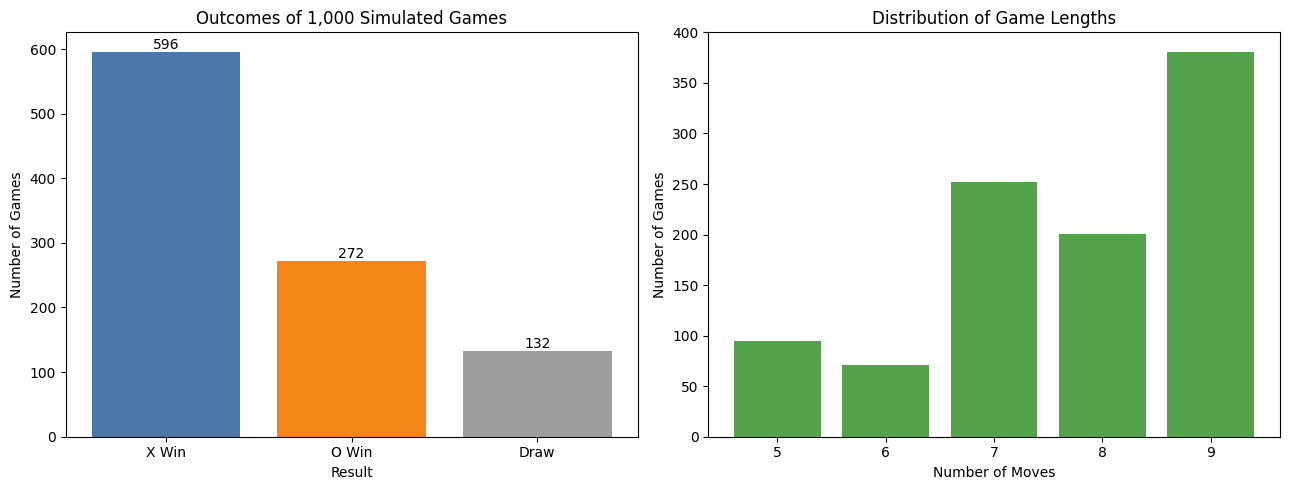

In [9]:
result_order = ['X Win', 'O Win', 'Draw']
result_counts = (
    gameplay_df['result'].value_counts().reindex(result_order, fill_value=0)
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

bars = axes[0].bar(
    result_counts.index,
    result_counts.values,
    color=['#4C78A8', '#F58518', '#9E9E9E'],
)
axes[0].set_title('Outcomes of 1,000 Simulated Games')
axes[0].set_xlabel('Result')
axes[0].set_ylabel('Number of Games')
axes[0].bar_label(bars)

move_counts = gameplay_df['number_of_moves'].value_counts().sort_index()
axes[1].bar(move_counts.index, move_counts.values, color='#54A24B')
axes[1].set_title('Distribution of Game Lengths')
axes[1].set_xlabel('Number of Moves')
axes[1].set_ylabel('Number of Games')
axes[1].set_xticks(range(5, 10))

plt.tight_layout()
plt.show()

## 7. Export the finalized gameplay data

In [10]:
output_filename = 'tic_tac_toe_gameplay_data.csv'
gameplay_df.to_csv(output_filename, index=False)
print(f'Saved {len(gameplay_df):,} rows to {output_filename}.')

Saved 1,000 rows to tic_tac_toe_gameplay_data.csv.


## 8. Basic findings

The simulation provides a reproducible dataset containing one row for every completed game. Because X always moves first, X is expected to have an advantage over O during random gameplay. Draws require all nine board positions to be used, while wins can occur earlier. The summary tables and charts above quantify the outcome frequencies and game lengths. These findings provide a baseline for the final presentation and for comparing random gameplay with a future strategy-based computer player.

## Next steps

1. Use the finalized DataFrame to select the clearest findings for the presentation.
2. Compare outcome percentages and average game lengths.
3. Explain the first-player advantage as a limitation of the simulation design.
4. Add a strategic computer player and compare its results with this random baseline.
5. Draft presentation slides covering the problem, design, data, algorithms, results, limitations, and conclusions.